In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.converters import circuit_to_dag,dag_to_circuit

import sys
sys.path.append("../")
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
import graphs_utils 
from testing_scripts.qaoa_utils import QAOASolver

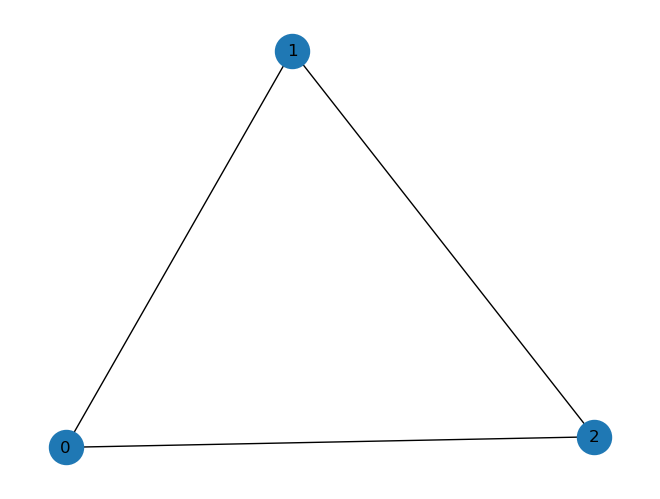

In [2]:
n = 3
k=3

G = graphs_utils.generate_random_complete_graph(num_vertices=n, weighted=True,seed=3)
# G=graphs_utils.generate_random_complete_graph(num_vertices=n, weighted=True, seed=2)
# G = graphs_utils.generate_random_ego_graph(num_nodes=n,weighted=True,seed=2)
# G = graphs_utils.generate_random_erdos_renyi_graph(num_nodes=n,probability=0.4,weighted=True,seed=4)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
# Optimal Maxcut Calculation
# optimal_max_cut_val = graphs_utils.compute_optimal_max_cut(G)
# print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

In [4]:

max_cut_paulis = graphs_utils.build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['IZZ', 'ZIZ', 'ZZI'],
              coeffs=[ 4.+0.j, 10.+0.j,  9.+0.j])
Number of terms : 3


In [5]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [ ]:
maxcut_qaoa = QAOASolver(cost_hamiltonian,circuit,sim_device="CPU")
maxcut_qaoa.prepare_circuit()
maxcut_qaoa.err= None

In [7]:
dag = circuit_to_dag(maxcut_qaoa.pcirc)
gate_types = list({node.name for node in dag.topological_op_nodes()})
print(gate_types)

['h', 'cx', 'rz', 's', 'sx']


In [8]:
assert len(maxcut_qaoa.stim_circ.gates) == maxcut_qaoa.pcirc.size()

In [ ]:
#Run CAFQA process
maxcut_qaoa.run_spiq(n_gens=2)

STARTING ROUND 0




started GA at id 1 with 8 procs
started GA at id 2 with 8 procs

started GA at id None with 8 procs

GA parameters used for this experiment:
  num_generations=1
  num_parents_mating=20
  population_size=100
  num_genes=12
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

started GA at id 3 with 8 procs
GA parameters used for this experiment:
  num_generations=1
  num_parents_mating=20
  population_size=100
  num_genes=12
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5GA parameters used for this experiment:
  num_generations=1
  num_parents_mating=20
  population_size=100
  num_genes=12
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probab

In [10]:
maxcut_qaoa.energy_best

np.float64(-15.0)

In [11]:
maxcut_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -15.0


np.float64(-15.0)

In [12]:
ordered_params = [param.name for param in maxcut_qaoa.pcirc.parameters]
angle_multipliers = [-np.pi/4 if 'gamma' in param else np.pi/4 for param in ordered_params]

random_params = np.random.uniform(0, 2 * np.pi, len(ordered_params))
cafqa_params = [param * (np.pi/2) for param, multiplier in zip(maxcut_qaoa.ks_best, angle_multipliers)] #This has to be in the order we come across the gates.

In [13]:
avg_energy = np.mean([maxcut_qaoa.evaluate_energy(maxcut_qaoa.pcirc, cost_hamiltonian, cafqa_params) for _ in range(10)])
avg_energy

np.float64(-11.041219672551716)

In [14]:
cafqa_result, cafqa_obj_values =maxcut_qaoa.run_qaoa(cafqa_params,max_iters=100,opt="COBYLA")
random_result, random_obj_values =maxcut_qaoa.run_qaoa(random_params,max_iters=100,opt="COBYLA")

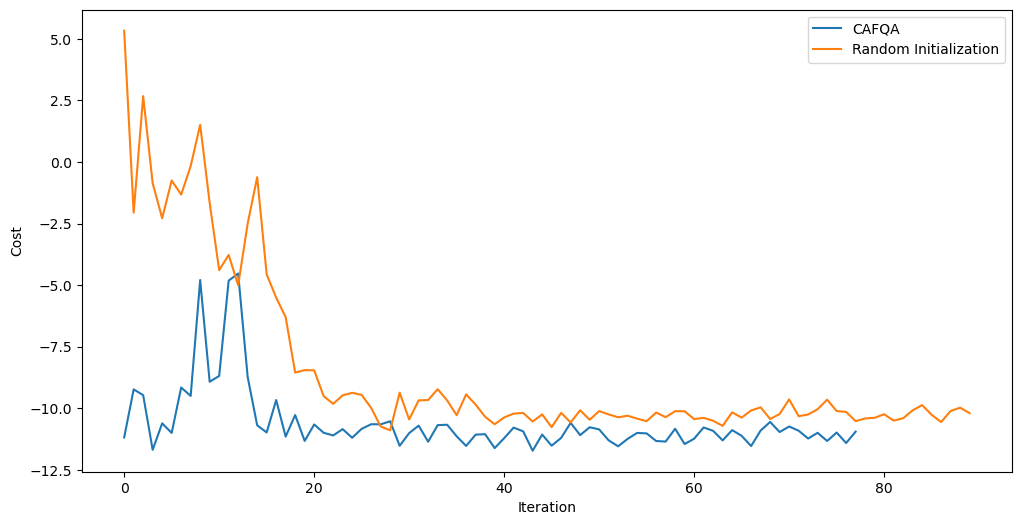

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_obj_values, label="CAFQA")
plt.plot(random_obj_values, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.show()

In [16]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
vanilla_teague = QAOASolver(cost_hamiltonian,circuit.decompose().decompose(),sim_device="CPU")
vanilla_teague.vanilla = True

In [17]:
import os
init_random_params = np.random.random(circuit.num_parameters)
res,obj_values=vanilla_teague.run_qaoa(init_random_params, max_iters=100)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

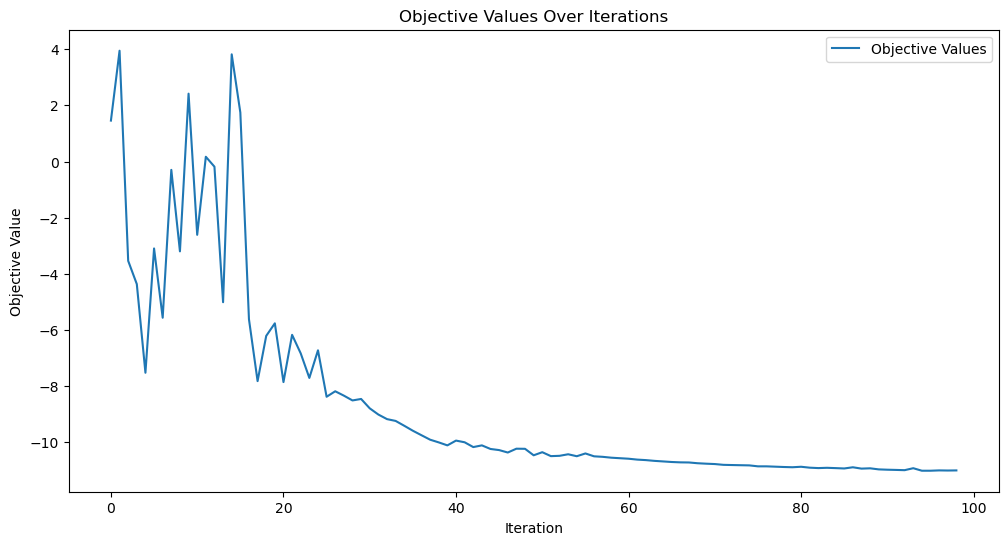

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()

In [19]:
# # import the data
# cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/12_qbs/result_7.npy', allow_pickle=True).item()
# random_result=cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['result']
# cafqa_result=cafqa_diff_points_data['Task_results']['task_1']['result']

In [20]:
optimized_circuit = maxcut_qaoa.pcirc.assign_parameters(random_result.x)
from qiskit.quantum_info import Statevector
state = Statevector(optimized_circuit).probabilities_dict(decimals=3)
len(state)

8

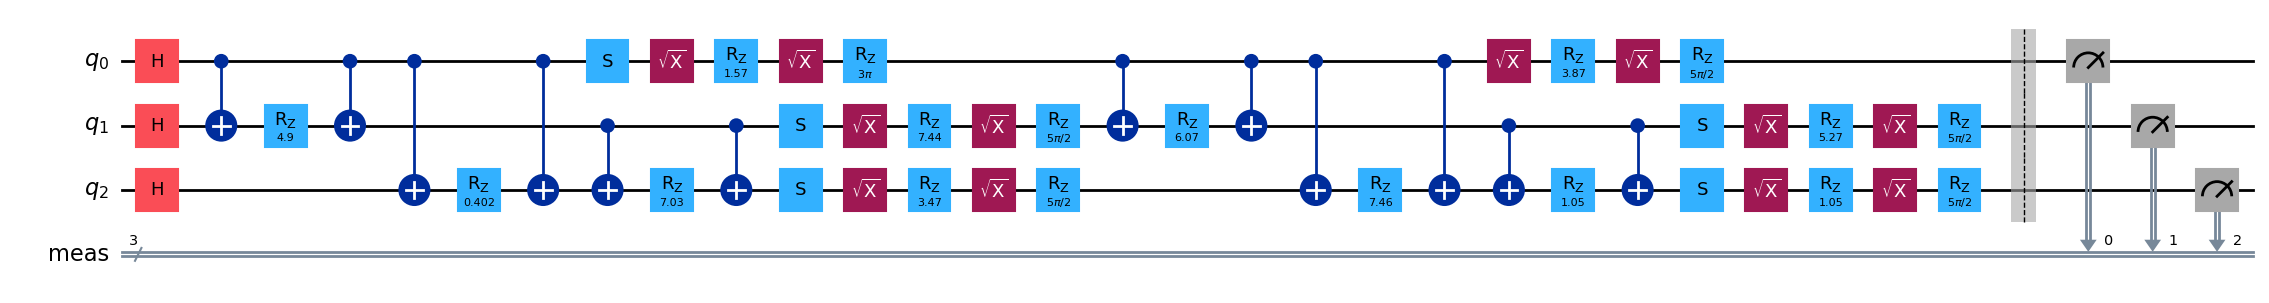

In [21]:
optimized_circuit.measure_all()
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [22]:
sampler = Sampler(mode=maxcut_qaoa.backend)
sampler.options.default_shots = 10000

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)
len(counts_int),len(counts_bin)

any_zero = any(value == 0 for value in final_distribution_int.values())
print("Is there any value equal to 0 in final_distribution_int?", any_zero)

{7: 0.0338, 3: 0.3394, 2: 0.0629, 4: 0.3568, 6: 0.0535, 5: 0.0629, 1: 0.0541, 0: 0.0366}
Is there any value equal to 0 in final_distribution_int? False


In [23]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    seq =  [int(digit) for digit in result]
    seq.reverse()
    return seq

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(G))
# most_likely_bitstring.reverse() #Added inside to_bitstring()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 1]


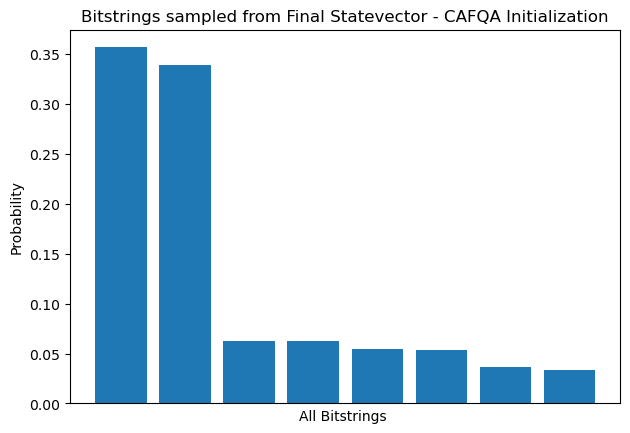

In [24]:
matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
# Get top 50 bitstrings by probability
sorted_items = sorted(final_bits.items(), key=lambda x: abs(x[1]), reverse=True)[:50]
bitstrings, probs = zip(*sorted_items)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=90)
plt.title("Bitstrings sampled from Final Statevector - CAFQA Initialization")
plt.xlabel("All Bitstrings ")
plt.ylabel("Probability")
ax.bar(bitstrings, probs, color="tab:blue")
plt.tight_layout()
ax.set_xticks([])
# plt.savefig('../plots/cafqa_states_12qb_barplot.png', dpi=500, bbox_inches='tight')
plt.show()

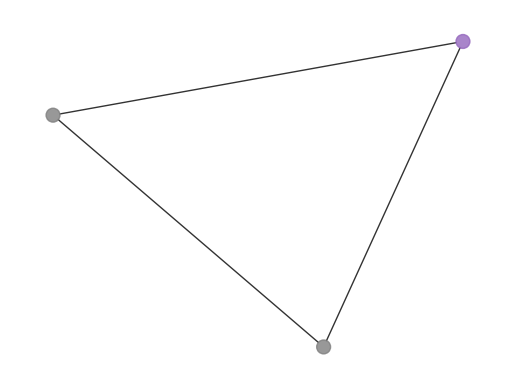

In [25]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(G, most_likely_bitstring)

In [26]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(w*(x[u] * (1 - x[v]) + x[v] * (1 - x[u])) for u, v,w in list(graph.weighted_edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, G)
print('The value of the cut is:', cut_value)

The value of the cut is: 19
